In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv("../data/processed/df_full.csv", nrows=100000)

In [10]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,8.0,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,8.0,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,8.0,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,8.0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,12.0,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [11]:
df.shape

(100000, 15)

In [12]:
df.isna().sum()

order_id                     0
product_id                   0
add_to_cart_order            0
reordered                    0
user_id                      0
eval_set                     0
order_number                 0
order_dow                    0
order_hour_of_day            0
days_since_prior_order    6241
product_name                 0
aisle_id                     0
department_id                0
aisle                        0
department                   0
dtype: int64

In [13]:
df = df.drop(columns="days_since_prior_order")

In [14]:
df.isna().sum()

order_id             0
product_id           0
add_to_cart_order    0
reordered            0
user_id              0
eval_set             0
order_number         0
order_dow            0
order_hour_of_day    0
product_name         0
aisle_id             0
department_id        0
aisle                0
department           0
dtype: int64

In [15]:
len(df)

100000

In [16]:
df.aisle.value_counts()

aisle
fresh fruits                  11186
fresh vegetables              10194
packaged vegetables fruits     5417
yogurt                         4460
packaged cheese                3035
                              ...  
specialty wines champagnes       25
beauty                           23
baby bath body care              22
eye ear care                     19
frozen juice                     18
Name: count, Length: 134, dtype: int64

In [19]:
df["aisle"].dtype

dtype('O')

In [20]:
df.head(20)

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,Natural Sweetener,17,13,baking ingredients,pantry
5,2,17794,6,1,202279,prior,3,5,9,Carrots,83,4,fresh vegetables,produce
6,2,40141,7,1,202279,prior,3,5,9,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry
7,2,1819,8,1,202279,prior,3,5,9,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry
8,2,43668,9,0,202279,prior,3,5,9,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce
9,3,33754,1,1,205970,prior,16,5,17,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs


In [21]:
df.order_hour_of_day.value_counts().sort_index()

order_hour_of_day
0      642
1      316
2      228
3      175
4      140
5      234
6      841
7     2798
8     5148
9     7844
10    7991
11    8228
12    8741
13    8013
14    8285
15    7990
16    7913
17    6553
18    4977
19    3798
20    3497
21    2476
22    2211
23     961
Name: count, dtype: int64

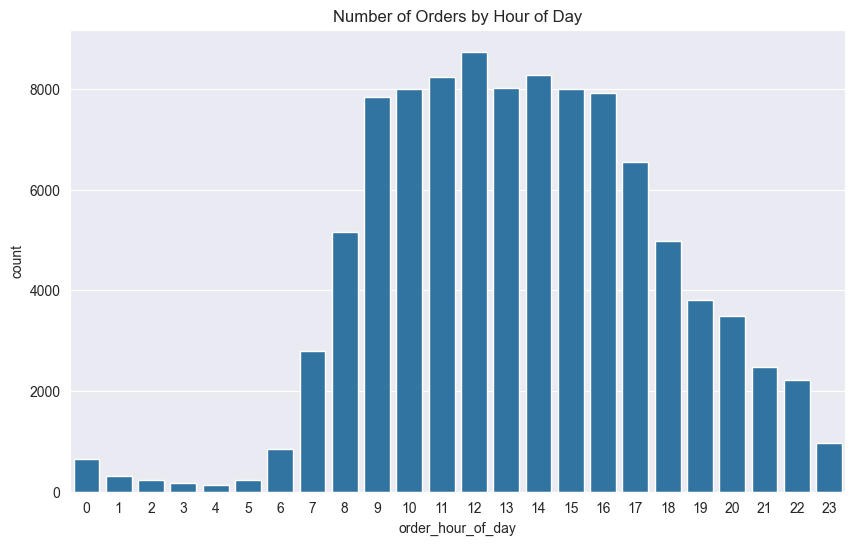

In [22]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='order_hour_of_day', data=df, ax=ax)
ax.set_title('Number of Orders by Hour of Day')
plt.show()

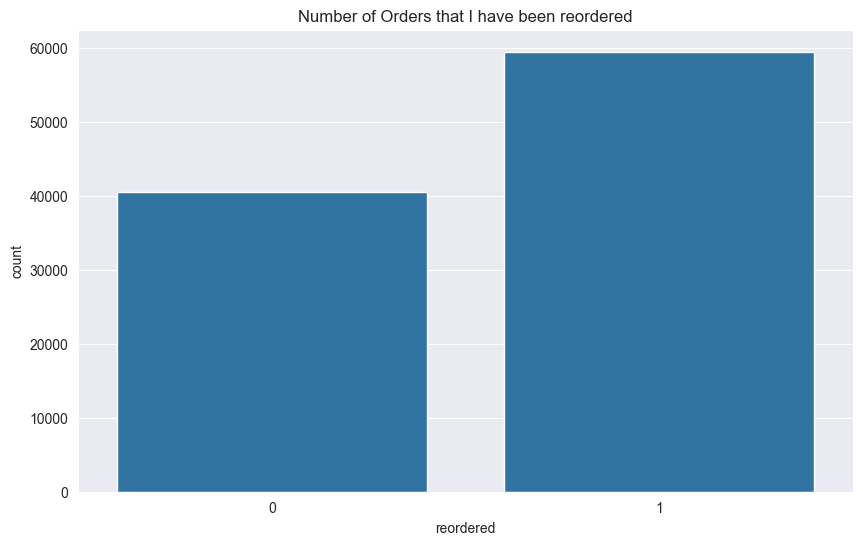

In [23]:
fig, ax = plt.subplots(figsize=(10,6))
sns.countplot(x='reordered', data=df, ax=ax)
ax.set_title('Number of Orders that I have been reordered')
plt.show()

In [26]:
df.reordered.value_counts(normalize=True)

reordered
1    0.59514
0    0.40486
Name: proportion, dtype: float64

In [27]:
df['aisle'].nunique()

134

In [28]:
df['department'].nunique()

21

In [29]:
df['product_name'].nunique()

16319

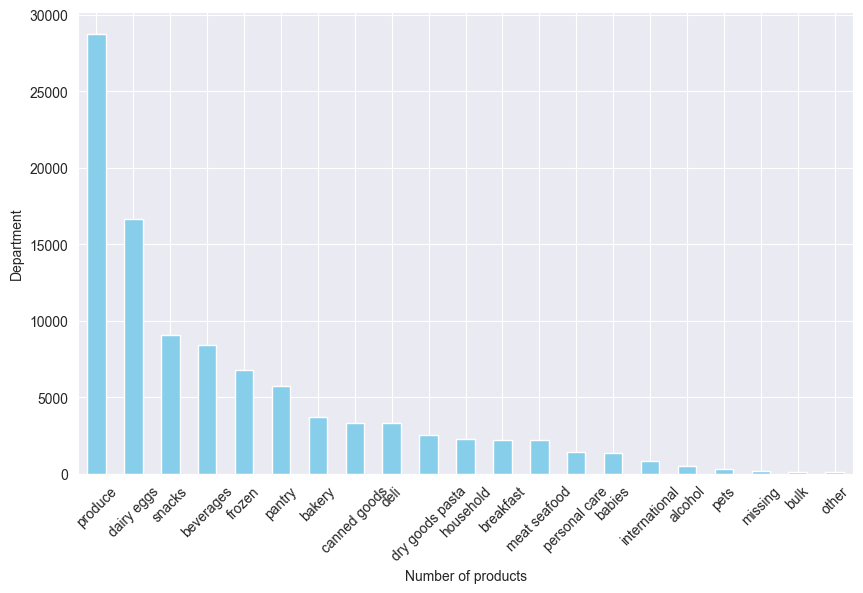

In [34]:
df['department'].value_counts().plot(kind='bar', color='skyblue', figsize=(10,6), rot=45)
plt.xlabel("Number of products")
plt.ylabel("Department")
plt.show()

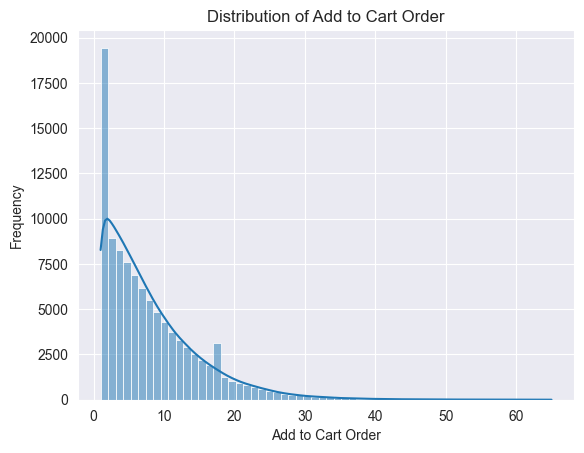

In [37]:
sns.histplot(x='add_to_cart_order', data=df, bins=60, kde=True)
plt.title("Distribution of Add to Cart Order")
plt.xlabel("Add to Cart Order")
plt.ylabel("Frequency")
plt.show()

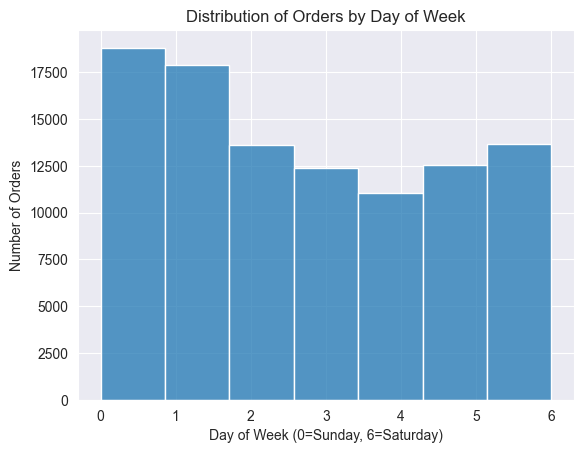

In [38]:
sns.histplot(x='order_dow', data=df, bins=7, kde=False)
plt.title("Distribution of Orders by Day of Week")
plt.xlabel("Day of Week (0=Sunday, 6=Saturday)")
plt.ylabel("Number of Orders")
plt.show()

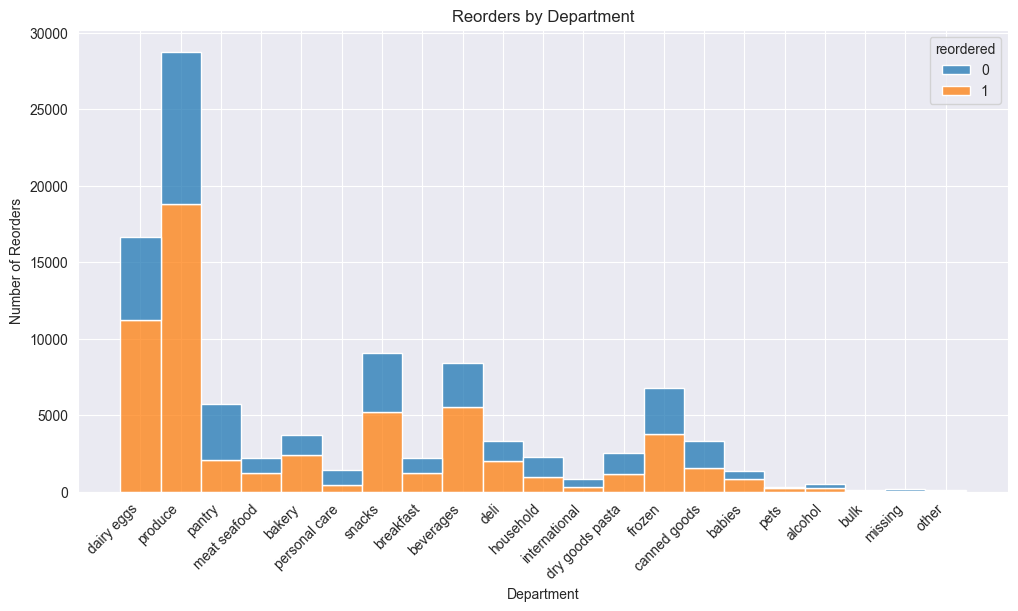

In [45]:
plt.figure(figsize=(12, 6))
sns.histplot(x='department', hue="reordered",data=df, multiple="stack")
plt.title("Reorders by Department")
plt.xlabel("Department")
plt.ylabel("Number of Reorders")
plt.xticks(rotation=45, ha='right')
plt.show()

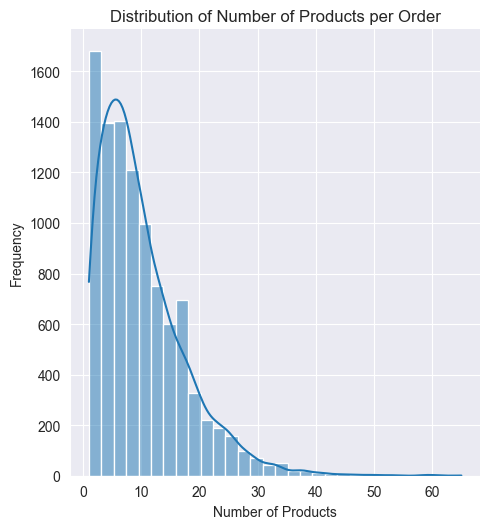

In [46]:
sns.displot(df.groupby('order_id').size(), bins=30, kde=True)
plt.title("Distribution of Number of Products per Order")
plt.xlabel("Number of Products")
plt.ylabel("Frequency")
plt.show()

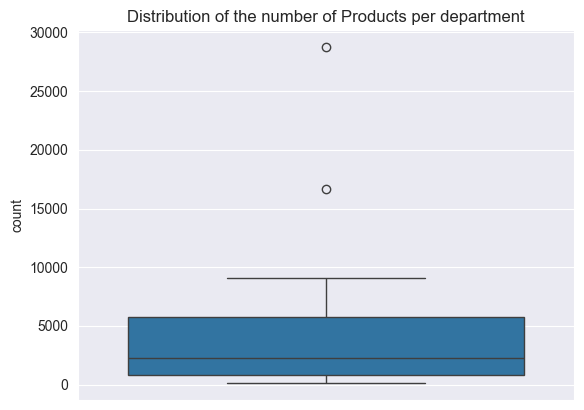

In [47]:
sns.boxplot(
    y=df['department'].value_counts()
)
plt.title("Distribution of the number of Products per department")
plt.show()